# Cross-Dataset Validation — Chapman-Shaoxing Model → Georgia

**Goal:** Test the model trained on Chapman-Shaoxing on the Georgia database to evaluate generalization.

**Training data:** Chapman-Shaoxing (12 leads, 500 Hz, 10s recordings, China)  
**Test data:** Georgia 12-Lead ECG Challenge Database (12 leads, 500 Hz, 10s recordings, USA)

No training — inference only using saved model weights.

### Metrics:
- Accuracy, Precision, Recall, F1, MCC, AUROC, AUPRC
- TN, FP, FN, TP
- ECE, MCE, Brier Score, Calibration Curves


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

!pip install wfdb -q
print('Drive mounted and dependencies installed.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 152.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
Drive mounted and dependencies installed.


## 1. Imports

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

In [3]:
class Config:
    afib_dir = ""
    normal_dir = ""

    # Trained model path
    model_path = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_model_12lead.pth"

    fs = 500
    num_channels = 12
    recording_seconds = 10
    recording_samples = fs * recording_seconds

    batch_size = 128
    num_classes = 2

    pdf_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_cross_dataset_georgia"

config = Config()
assert os.path.exists(config.model_path), f"Model not found: {config.model_path}"
os.makedirs(config.pdf_dir, exist_ok=True)

print(f"Model path: {config.model_path}")
print(f"Sampling rate: {config.fs} Hz")
print(f"Input: {config.recording_samples} samples ({config.recording_seconds}s, no windowing)")
print("Config ready.")

Model path: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_model_12lead.pth
Sampling rate: 500 Hz
Input: 5000 samples (10s, no windowing)
Config ready.


## 3. Unzip Georgia Data to Local Disk

In [4]:
import os

if not os.path.exists("/content/georgia_data"):
    print("Unzipping Georgia subset to local disk...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/georgia_afib_normal_subset.zip" -d /content/georgia_data/
    print("Unzip complete!")
    print("Contents:", os.listdir("/content/georgia_data/"))

# Auto-detect folder structure
for base in ["/content/georgia_data",
             "/content/georgia_data/georgia_afib_normal_subset"]:
    afib_path = os.path.join(base, "afib")
    normal_path = os.path.join(base, "normal")
    if os.path.exists(afib_path) and os.path.exists(normal_path):
        config.afib_dir = afib_path
        config.normal_dir = normal_path
        break

print(f"AFib records: {len([f for f in os.listdir(config.afib_dir) if f.endswith('.hea')])}")
print(f"Normal records: {len([f for f in os.listdir(config.normal_dir) if f.endswith('.hea')])}")
print("Using local disk.")

Unzipping Georgia subset to local disk...
Unzip complete!
Contents: ['georgia_afib_normal_subset']
AFib records: 570
Normal records: 1752
Using local disk.


## 4. Model Definition (Must match training architecture)

In [5]:
class KanResInit(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride)
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2)
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        return x

class KanResModule(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride, padding='same')
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2, padding='same')
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = out + identity
        return out

class KanResWideX(nn.Module):
    def __init__(self, input_channels=12, output_size=2):
        super().__init__()
        self.init_block = KanResInit(input_channels, 64, 32, 8, 3, 1)
        self.pool = nn.AvgPool1d(kernel_size=2)
        self.res_modules = nn.ModuleList([
            KanResModule(32, 64, 32, 50, 50, 1) for _ in range(8)
        ])
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, output_size)

    def forward(self, x):
        x = self.init_block(x)
        x = self.pool(x)
        for res_module in self.res_modules:
            x = res_module(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

print("Model defined.")

Model defined.


## 5. Load Trained Model

In [6]:
model = KanResWideX(input_channels=config.num_channels, output_size=config.num_classes).to(device)
state_dict = torch.load(config.model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded from: {config.model_path}")
print(f"Total parameters: {total_params:,}")

Model loaded from: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_model_12lead.pth
Total parameters: 1,653,346


## 6. Discover Georgia Records

In [7]:
afib_files = sorted([f[:-4] for f in os.listdir(config.afib_dir) if f.endswith('.hea')])
normal_files = sorted([f[:-4] for f in os.listdir(config.normal_dir) if f.endswith('.hea')])

all_records = []
for name in afib_files:
    all_records.append({"path": os.path.join(config.afib_dir, name), "name": name, "label": 1})
for name in normal_files:
    all_records.append({"path": os.path.join(config.normal_dir, name), "name": name, "label": 0})

print(f"Georgia Subset:")
print(f"  AFib records:   {len(afib_files)}")
print(f"  Normal records: {len(normal_files)}")
print(f"  Total:          {len(all_records)}")
print(f"  AFib prevalence: {len(afib_files)/len(all_records):.2%}")

Georgia Subset:
  AFib records:   570
  Normal records: 1752
  Total:          2322
  AFib prevalence: 24.55%


## 7. Load and Preprocess (Full 10s, No Windowing)

In [8]:
def load_record(record_info, config):
    try:
        rec = wfdb.rdrecord(record_info["path"])
        signal = rec.p_signal
    except Exception as e:
        return None, None

    if signal.shape[1] < config.num_channels:
        return None, None

    if np.any(np.isnan(signal)):
        return None, None

    if len(signal) < config.recording_samples:
        pad = np.zeros((config.recording_samples - len(signal), config.num_channels))
        signal = np.vstack([signal, pad])
    elif len(signal) > config.recording_samples:
        signal = signal[:config.recording_samples, :]

    for ch in range(config.num_channels):
        std = np.std(signal[:, ch])
        if std < 1e-6:
            signal[:, ch] = np.random.normal(0, 1e-4, len(signal[:, ch]))
        else:
            signal[:, ch] = (signal[:, ch] - np.mean(signal[:, ch])) / std

    sample = signal[:, :config.num_channels].T.copy().astype(np.float32)
    label = np.int64(record_info["label"])
    return sample, label

s, l = load_record(all_records[0], config)
if s is not None:
    print(f"Test: {all_records[0]['name']} -> shape {s.shape}, label={l}")
else:
    print("Failed to load test record")

Failed to load test record


In [10]:
# Debug: try loading one record and show the error
rec = all_records[0]
print(f"Path: {rec['path']}")
print(f"Exists .hea: {os.path.exists(rec['path'] + '.hea')}")
print(f"Exists .mat: {os.path.exists(rec['path'] + '.mat')}")
print(f"Exists .dat: {os.path.exists(rec['path'] + '.dat')}")

try:
    record = wfdb.rdrecord(rec['path'])
    print(f"Signal shape: {record.p_signal.shape}")
    print(f"Channels: {record.sig_name}")
except Exception as e:
    print(f"ERROR: {e}")

Path: /content/georgia_data/georgia_afib_normal_subset/afib/E00005
Exists .hea: True
Exists .mat: True
Exists .dat: False
ERROR: invalid syntax in record line


In [11]:
with open("/content/georgia_data/georgia_afib_normal_subset/afib/E00005.hea", 'r') as f:
    print(f.read())

E00005.mat 12 500 5000 05-May-2020 14:50:55
E00005.mat 16+24 4880/mV 16 0 -39 24283 0 I
E00005.mat 16+24 4880/mV 16 0 -97 29135 0 II
E00005.mat 16+24 4880/mV 16 0 -58 5030 0 III
E00005.mat 16+24 4880/mV 16 0 68 -26732 0 aVR
E00005.mat 16+24 4880/mV 16 0 9 9787 0 aVL
E00005.mat 16+24 4880/mV 16 0 -78 17147 0 aVF
E00005.mat 16+24 4880/mV 16 0 0 -4448 0 V1
E00005.mat 16+24 4880/mV 16 0 -82 27846 0 V2
E00005.mat 16+24 4880/mV 16 0 -73 -20390 0 V3
E00005.mat 16+24 4880/mV 16 0 -63 -9060 0 V4
E00005.mat 16+24 4880/mV 16 0 -58 -24048 0 V5
E00005.mat 16+24 4880/mV 16 0 -53 -1905 0 V6
#Age: 83
#Sex: Male
#Dx: 59118001,164889003
#Rx: Unknown
#Hx: Unknown
#Sx: Unknown



In [12]:
import re

# Fix Georgia .hea files - remove .mat extension and timestamp from first line
fixed = 0
for folder in [config.afib_dir, config.normal_dir]:
    for fname in os.listdir(folder):
        if fname.endswith('.hea'):
            fpath = os.path.join(folder, fname)
            with open(fpath, 'r') as f:
                lines = f.readlines()

            # Fix first line: "E00005.mat 12 500 5000 05-May-2020 14:50:55"
            # -> "E00005 12 500 5000"
            first_line = lines[0].strip().split()
            record_name = first_line[0].replace('.mat', '')
            n_sig = first_line[1]
            fs = first_line[2]
            n_samp = first_line[3]
            lines[0] = f"{record_name} {n_sig} {fs} {n_samp}\n"

            with open(fpath, 'w') as f:
                f.writelines(lines)
            fixed += 1

print(f"Fixed {fixed} .hea files")

# Test
rec = all_records[0]
try:
    record = wfdb.rdrecord(rec['path'])
    print(f"Test: {rec['name']} -> shape {record.p_signal.shape}")
    print("Fix successful!")
except Exception as e:
    print(f"Still failing: {e}")

Fixed 2322 .hea files
Test: E00005 -> shape (5000, 12)
Fix successful!


## 8. Load All Georgia Records

In [13]:
print(f"Loading {len(all_records)} records...")
start_time = time.time()

all_samples = []
all_labels = []
skipped = 0
loaded_afib = 0
loaded_normal = 0

for i, rec in enumerate(all_records):
    if (i + 1) % 500 == 0:
        elapsed = time.time() - start_time
        print(f"  Processed {i+1}/{len(all_records)} ({elapsed:.0f}s)...")

    sample, label = load_record(rec, config)
    if sample is not None:
        all_samples.append(sample)
        all_labels.append(label)
        if label == 1:
            loaded_afib += 1
        else:
            loaded_normal += 1
    else:
        skipped += 1

all_samples = np.array(all_samples, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int64)

load_time = time.time() - start_time
print(f"\nLoading complete in {load_time/60:.1f} minutes")
print(f"Records loaded: {len(all_labels)} (skipped: {skipped})")
print(f"  AFib:   {loaded_afib}")
print(f"  Normal: {loaded_normal}")
print(f"  AFib prevalence: {loaded_afib/len(all_labels):.2%}")

Loading 2322 records...
  Processed 500/2322 (5s)...
  Processed 1000/2322 (10s)...
  Processed 1500/2322 (15s)...
  Processed 2000/2322 (20s)...

Loading complete in 0.4 minutes
Records loaded: 2321 (skipped: 1)
  AFib:   570
  Normal: 1751
  AFib prevalence: 24.56%


## 9. Run Inference

In [14]:
class ECGDataset(Dataset):
    def __init__(self, samples, labels):
        self.samples = torch.FloatTensor(samples)
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

test_loader = DataLoader(ECGDataset(all_samples, all_labels),
                         batch_size=config.batch_size, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"Running inference on {len(all_labels):,} samples...")
start_time = time.time()

all_preds = []
all_targets = []
all_probs = []

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

inference_time = time.time() - start_time
print(f"Inference complete in {inference_time:.1f} seconds")

Running inference on 2,321 samples...
Inference complete in 1.9 seconds


## 10. Compute All Metrics

In [15]:
cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds, pos_label=1, zero_division=0)
rec = recall_score(all_targets, all_preds, pos_label=1, zero_division=0)
f1 = f1_score(all_targets, all_preds, pos_label=1, zero_division=0)
mcc = matthews_corrcoef(all_targets, all_preds)
auroc = roc_auc_score(all_targets, all_probs)
auprc = average_precision_score(all_targets, all_probs)
brier = brier_score_loss(all_targets, all_probs)

n_bins = 10
bin_boundaries = np.linspace(0, 1, n_bins + 1)
ece, mce = 0.0, 0.0
for i in range(n_bins):
    if i < n_bins - 1:
        mask = (all_probs >= bin_boundaries[i]) & (all_probs < bin_boundaries[i + 1])
    else:
        mask = (all_probs >= bin_boundaries[i]) & (all_probs <= bin_boundaries[i + 1])
    bin_count = mask.sum()
    if bin_count > 0:
        bin_acc = all_targets[mask].mean()
        bin_conf = all_probs[mask].mean()
        cal_error = abs(bin_acc - bin_conf)
        ece += (bin_count / len(all_targets)) * cal_error
        mce = max(mce, cal_error)

print("=" * 65)
print("CROSS-DATASET VALIDATION RESULTS")
print("Trained on: Chapman-Shaoxing | Tested on: Georgia")
print("=" * 65)
print(f"  Accuracy:   {acc:.4f}")
print(f"  Precision:  {prec:.4f}")
print(f"  Recall:     {rec:.4f}")
print(f"  F1:         {f1:.4f}")
print(f"  MCC:        {mcc:.4f}")
print(f"  AUROC:      {auroc:.4f}")
print(f"  AUPRC:      {auprc:.4f}")
print(f"  Brier:      {brier:.4f}")
print(f"  ECE:        {ece:.4f}")
print(f"  MCE:        {mce:.4f}")
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print()
print(classification_report(all_targets, all_preds, target_names=["Normal", "AFib"]))

CROSS-DATASET VALIDATION RESULTS
Trained on: Chapman-Shaoxing | Tested on: Georgia
  Accuracy:   0.9526
  Precision:  0.9957
  Recall:     0.8105
  F1:         0.8936
  MCC:        0.8711
  AUROC:      0.9481
  AUPRC:      0.9388
  Brier:      0.0446
  ECE:        0.0464
  MCE:        0.8746
  TN=1749  FP=2  FN=108  TP=462

              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97      1751
        AFib       1.00      0.81      0.89       570

    accuracy                           0.95      2321
   macro avg       0.97      0.90      0.93      2321
weighted avg       0.96      0.95      0.95      2321



## 11. Confusion Matrix

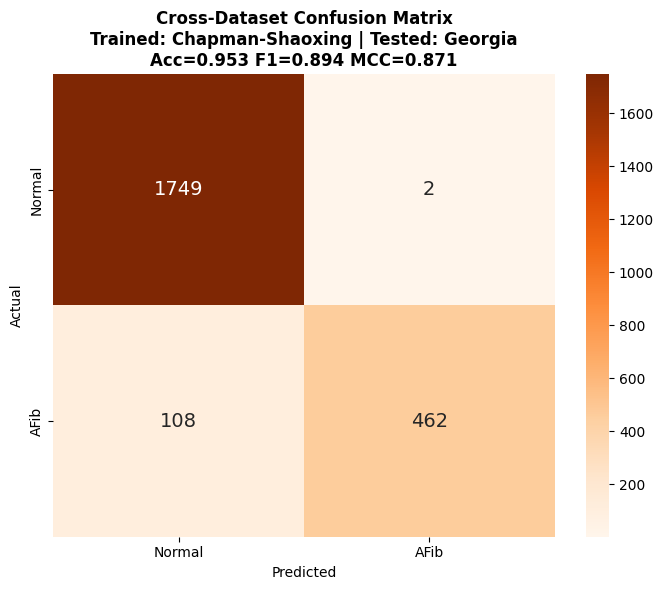

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Normal", "AFib"], yticklabels=["Normal", "AFib"],
            ax=ax, annot_kws={"size": 14})
ax.set_title(f"Cross-Dataset Confusion Matrix\nTrained: Chapman-Shaoxing | Tested: Georgia\nAcc={acc:.3f} F1={f1:.3f} MCC={mcc:.3f}", fontsize=12, fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "georgia_confusion_matrix.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 12. ROC Curve

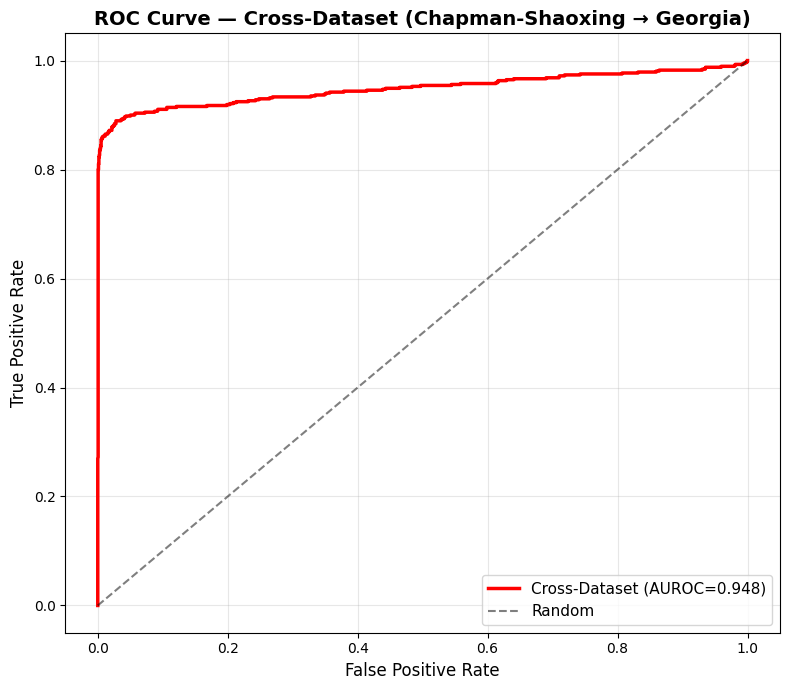

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
fpr, tpr, _ = roc_curve(all_targets, all_probs)
ax.plot(fpr, tpr, color='red', linewidth=2.5, label=f'Cross-Dataset (AUROC={auroc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Cross-Dataset (Chapman-Shaoxing → Georgia)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "georgia_roc.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 13. Precision-Recall Curve

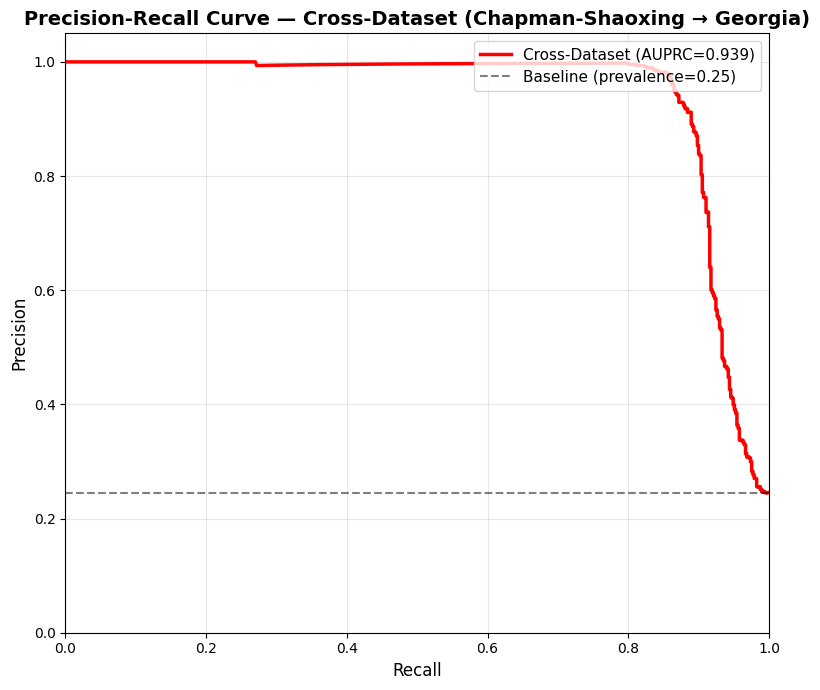

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))
prec_c, rec_c, _ = precision_recall_curve(all_targets, all_probs)
ax.plot(rec_c, prec_c, color='red', linewidth=2.5, label=f'Cross-Dataset (AUPRC={auprc:.3f})')
baseline = np.mean(all_targets)
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline (prevalence={baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Cross-Dataset (Chapman-Shaoxing → Georgia)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "georgia_pr.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 14. Calibration Plot

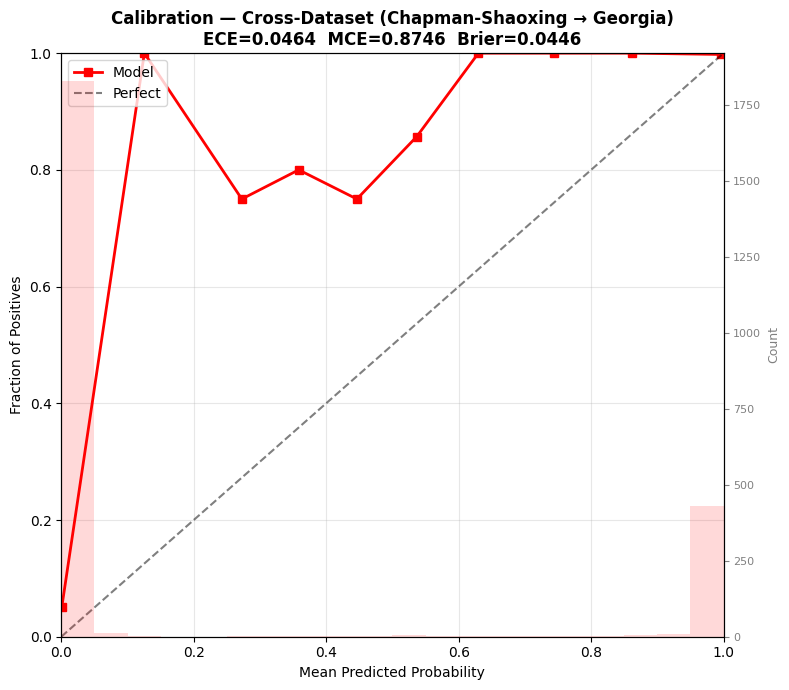

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))
fraction_pos, mean_predicted = calibration_curve(all_targets, all_probs, n_bins=10, strategy='uniform')
ax.plot(mean_predicted, fraction_pos, 's-', color='red', linewidth=2, markersize=6, label='Model')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
ax2 = ax.twinx()
ax2.hist(all_probs, bins=20, range=(0, 1), alpha=0.15, color='red')
ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
ax2.tick_params(axis='y', labelsize=8, colors='gray')
ax.set_title(f"Calibration — Cross-Dataset (Chapman-Shaoxing → Georgia)\nECE={ece:.4f}  MCE={mce:.4f}  Brier={brier:.4f}", fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "georgia_calibration.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 15. Predicted Probability Distribution

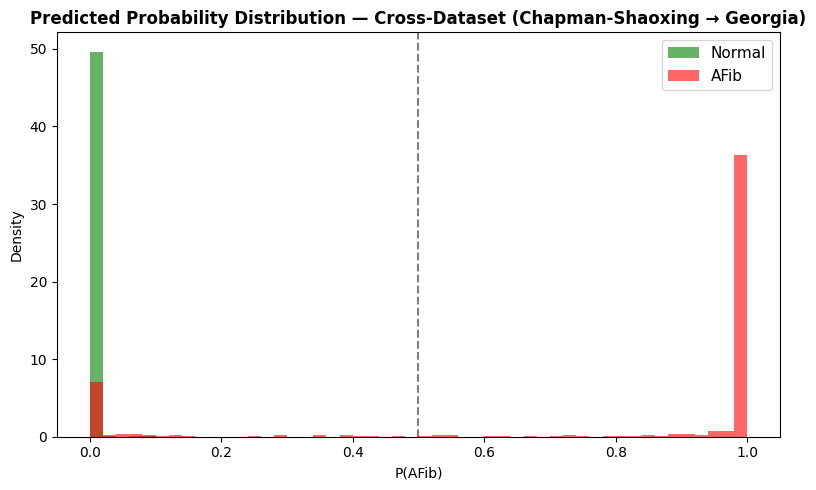

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
mask_neg = all_targets == 0
mask_pos = all_targets == 1
ax.hist(all_probs[mask_neg], bins=50, range=(0, 1), alpha=0.6, color='green', label='Normal', density=True)
ax.hist(all_probs[mask_pos], bins=50, range=(0, 1), alpha=0.6, color='red', label='AFib', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
ax.set_title("Predicted Probability Distribution — Cross-Dataset (Chapman-Shaoxing → Georgia)", fontsize=12, fontweight='bold')
ax.set_xlabel("P(AFib)"); ax.set_ylabel("Density")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "georgia_prob_dist.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 16. Final Summary

In [21]:
print("=" * 70)
print("CROSS-DATASET VALIDATION SUMMARY")
print("=" * 70)
print()
print("Training dataset:  Chapman-Shaoxing (12-lead, 500 Hz, 10s, China)")
print(f"  Model: KanResWideX (12-channel), best fold from 5-fold CV")
print()
print("Testing dataset:   Georgia (12-lead, 500 Hz, 10s, USA)")
print(f"  Records loaded: {len(all_labels):,} (AFib: {loaded_afib}, Normal: {loaded_normal})")
print(f"  AFib prevalence: {loaded_afib/len(all_labels):.2%}")
print()
print(f"{'Metric':<15} {'Value':<10}")
print("-" * 25)
for name, val in [("Accuracy", acc), ("Precision", prec), ("Recall", rec),
                   ("F1", f1), ("MCC", mcc), ("AUROC", auroc), ("AUPRC", auprc),
                   ("Brier", brier), ("ECE", ece), ("MCE", mce)]:
    print(f"{name:<15} {val:.4f}")
print()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print()
print(f"Inference time: {inference_time:.1f} seconds")
print()

# Comparison table
print("=" * 70)
print("COMPARISON: Chapman-Shaoxing CV vs PTB-XL Cross vs Georgia Cross")
print("=" * 70)
print(f"{'Metric':<15} {'Chapman (CV)':<18} {'PTB-XL':<18} {'Georgia':<18}")
print("-" * 70)
print(f"{'Accuracy':<15} {'0.9939':<18} {'0.9900':<18} {acc:.4f}")
print(f"{'Precision':<15} {'0.9726':<18} {'0.9698':<18} {prec:.4f}")
print(f"{'Recall':<15} {'0.9949':<18} {'0.9553':<18} {rec:.4f}")
print(f"{'F1':<15} {'0.9836':<18} {'0.9625':<18} {f1:.4f}")
print(f"{'MCC':<15} {'0.9800':<18} {'0.9567':<18} {mcc:.4f}")
print(f"{'AUROC':<15} {'0.9994':<18} {'0.9950':<18} {auroc:.4f}")
print(f"{'Brier':<15} {'0.0048':<18} {'0.0085':<18} {brier:.4f}")
print(f"{'ECE':<15} {'0.0048':<18} {'0.0057':<18} {ece:.4f}")
print(f"{'MCE':<15} {'0.6711':<18} {'0.2833':<18} {mce:.4f}")

CROSS-DATASET VALIDATION SUMMARY

Training dataset:  Chapman-Shaoxing (12-lead, 500 Hz, 10s, China)
  Model: KanResWideX (12-channel), best fold from 5-fold CV

Testing dataset:   Georgia (12-lead, 500 Hz, 10s, USA)
  Records loaded: 2,321 (AFib: 570, Normal: 1751)
  AFib prevalence: 24.56%

Metric          Value     
-------------------------
Accuracy        0.9526
Precision       0.9957
Recall          0.8105
F1              0.8936
MCC             0.8711
AUROC           0.9481
AUPRC           0.9388
Brier           0.0446
ECE             0.0464
MCE             0.8746

TN=1749  FP=2  FN=108  TP=462

Inference time: 1.9 seconds

COMPARISON: Chapman-Shaoxing CV vs PTB-XL Cross vs Georgia Cross
Metric          Chapman (CV)       PTB-XL             Georgia           
----------------------------------------------------------------------
Accuracy        0.9939             0.9900             0.9526
Precision       0.9726             0.9698             0.9957
Recall          0.9949          